# Библиотеки

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # основная библиотека для визуализации данных
import seaborn as sns # библиотека для статистической визуализации данных
from scipy.sparse import hstack # горизонтальное объединение разреженных матриц
import zipfile  # для работы с ZIP-архивами

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/flight-delays-fall-2018/sample_submission.csv.zip
/kaggle/input/competitions/flight-delays-fall-2018/flight_delays_train.csv.zip
/kaggle/input/competitions/flight-delays-fall-2018/flight_delays_test.csv.zip


# Настройка отображения и проверка доступных данных:

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

DATA_PATH = '/kaggle/input/competitions/flight-delays-fall-2018'
print("Доступные файлы:", os.listdir(DATA_PATH))

Доступные файлы: ['sample_submission.csv.zip', 'flight_delays_train.csv.zip', 'flight_delays_test.csv.zip']


# Функция для разархивации и загрузки CSV:

In [3]:
def load_csv_from_zip(zip_filename):
    zip_path = os.path.join(DATA_PATH, zip_filename)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        # Получаем имя CSV файла внутри архива
        csv_filename = zip_filename.replace('.zip', '')
        with zip_ref.open(csv_filename) as csv_file:
            return pd.read_csv(csv_file)

# Загрузка данных с разархивацией:

In [4]:
train = load_csv_from_zip('flight_delays_train.csv.zip')
test = load_csv_from_zip('flight_delays_test.csv.zip')
sample_submission = load_csv_from_zip('sample_submission.csv.zip')

print(f"Train загружен: {train.shape}")
print(f"Test загружен: {test.shape}")
print(f"Sample Submission загружен: {sample_submission.shape}")

Train загружен: (100000, 9)
Test загружен: (100000, 8)
Sample Submission загружен: (100000, 2)


# Базовая информация о данных:

In [5]:
print("ПЕРВЫЕ 5 СТРОК TRAIN:")
print("\n")
print(train.head())

print("\n")
print("ИНФОРМАЦИЯ О TRAIN:")
print("\n")
print(train.info())

print("\n")
print("СТАТИСТИКА TRAIN (категориальные признаки):")
print("\n")
print(train.describe(include='all'))

print("\n")
print("ПРОВЕРКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ В TRAIN:")
print("\n")
print(train.isnull().sum())

ПЕРВЫЕ 5 СТРОК TRAIN:


  Month DayofMonth DayOfWeek  DepTime UniqueCarrier Origin Dest  Distance  \
0   c-8       c-21       c-7     1934            AA    ATL  DFW       732   
1   c-4       c-20       c-3     1548            US    PIT  MCO       834   
2   c-9        c-2       c-5     1422            XE    RDU  CLE       416   
3  c-11       c-25       c-6     1015            OO    DEN  MEM       872   
4  c-10        c-7       c-6     1828            WN    MDW  OMA       423   

  dep_delayed_15min  
0                 N  
1                 N  
2                 N  
3                 N  
4                 Y  


ИНФОРМАЦИЯ О TRAIN:


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Month              100000 non-null  object
 1   DayofMonth         100000 non-null  object
 2   DayOfWeek          100000 non-null  object
 3   Dep

# ETL (преобразование данных):

In [6]:
def transform(df, is_train=True):
    #Функция для предобработки данных
    df = df.copy()
    print(f"\nПреобразование данных... (train={is_train})")
    print(f"Исходная форма: {df.shape}")
    # Преобразование полей 'c-8', 'c-21', 'c-7' в числа
    for col in ['Month', 'DayofMonth', 'DayOfWeek']:
        if col in df.columns:
            print(f"  - Преобразование {col}...")
            # Удаляем префикс 'c-' и преобразуем в int
            df[col] = df[col].str.replace('c-', '', regex=False).astype(int)
    # Извлечение часа вылета из DepTime (формат HHMM)
    if 'DepTime' in df.columns:
        print(f"  - Извлечение часа вылета из DepTime...")
        # Обработка пропущенных значений в DepTime
        df['DepHour'] = (df['DepTime'] // 100).clip(0, 23).astype(int)
    # Признак выходного дня (суббота = 6, воскресенье = 7)
    if 'DayOfWeek' in df.columns:
        print(f"  - Создание признака выходного дня...")
        df['IsWeekend'] = (df['DayOfWeek'] >= 6).astype(int)
    # Создание целевой переменной для train
    if is_train and 'dep_delayed_15min' in df.columns:
        print(f"  - Создание целевой переменной...")
        df['target'] = (df['dep_delayed_15min'] == 'Y').astype(int)
        print(f"    Распределение target: {df['target'].value_counts().to_dict()}")
    print(f"Результат: {df.shape}")
    return df
# Применяем преобразования
print("\n")
print("ПРИМЕНЕНИЕ ETL ПАЙПЛАЙНА:")
print("\n")

train_processed = transform(train, is_train=True)
test_processed = transform(test, is_train=False)

# Проверка результатов
print("\n")
print("РЕЗУЛЬТАТЫ ПРЕОБРАЗОВАНИЯ:")
print("\n")
print(f"Train: {train_processed.shape}")
print(f"Test: {test_processed.shape}")

print("\nПервые 5 строк обработанного Train:")
print(train_processed.head())

print("\nТипы данных после преобразования:")
print(train_processed.dtypes)

# Сохранение обработанных данных в Parquet
os.makedirs('/kaggle/working', exist_ok=True)
train_processed.to_parquet('/kaggle/working/train_processed.parquet', index=False)
test_processed.to_parquet('/kaggle/working/test_processed.parquet', index=False)
print("\n Данные сохранены в /kaggle/working/ в формате Parquet")



ПРИМЕНЕНИЕ ETL ПАЙПЛАЙНА:



Преобразование данных... (train=True)
Исходная форма: (100000, 9)
  - Преобразование Month...
  - Преобразование DayofMonth...
  - Преобразование DayOfWeek...
  - Извлечение часа вылета из DepTime...
  - Создание признака выходного дня...
  - Создание целевой переменной...
    Распределение target: {0: 80956, 1: 19044}
Результат: (100000, 12)

Преобразование данных... (train=False)
Исходная форма: (100000, 8)
  - Преобразование Month...
  - Преобразование DayofMonth...
  - Преобразование DayOfWeek...
  - Извлечение часа вылета из DepTime...
  - Создание признака выходного дня...
Результат: (100000, 10)


РЕЗУЛЬТАТЫ ПРЕОБРАЗОВАНИЯ:


Train: (100000, 12)
Test: (100000, 10)

Первые 5 строк обработанного Train:
   Month  DayofMonth  DayOfWeek  DepTime UniqueCarrier Origin Dest  Distance  \
0      8          21          7     1934            AA    ATL  DFW       732   
1      4          20          3     1548            US    PIT  MCO       834   
2      9    

Баланас классов:

In [7]:
print("\n")
print("БАЛАНС КЛАССОВ:")
print("\n")
# Проверяем, что target существует
if 'target' in train_processed.columns:
    class_distribution = train_processed['target'].value_counts()
    delay_rate = train_processed['target'].mean()
    
    print(f"Доля задержанных рейсов: {delay_rate:.3f} ({delay_rate*100:.1f}%)")
    print(f"0 (нет задержки): {class_distribution[0]:,} ({class_distribution[0]/len(train_processed)*100:.1f}%)")
    print(f"1 (задержка > 15 мин): {class_distribution[1]:,} ({class_distribution[1]/len(train_processed)*100:.1f}%)")
else:
    print("Внимание: целевая переменная 'target' не найдена!")
    print("Доступные колонки:", train_processed.columns.tolist())



БАЛАНС КЛАССОВ:


Доля задержанных рейсов: 0.190 (19.0%)
0 (нет задержки): 80,956 (81.0%)
1 (задержка > 15 мин): 19,044 (19.0%)


Визуализации

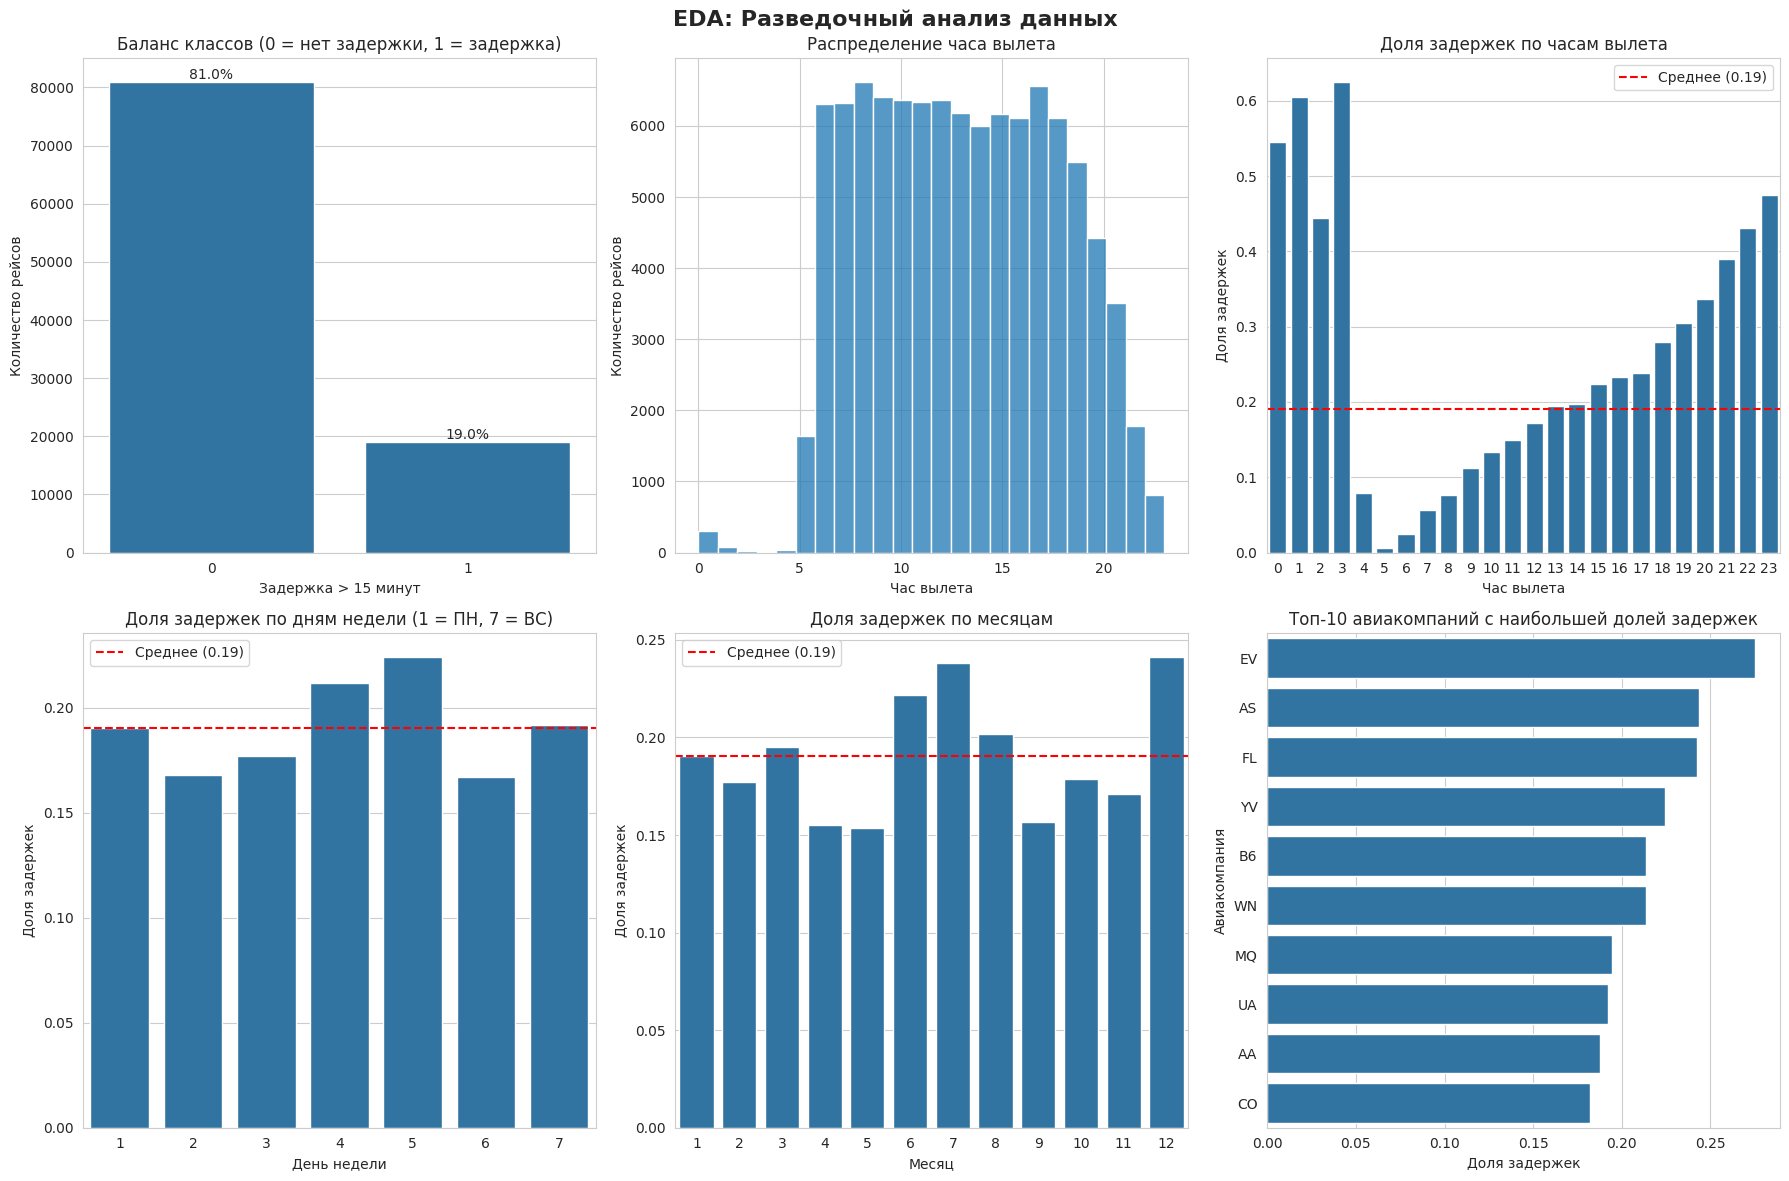

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('EDA: Разведочный анализ данных', fontsize=16, fontweight='bold')

# График 1: Баланс классов
if 'target' in train_processed.columns:
    sns.countplot(x='target', data=train_processed, ax=axes[0,0])
    axes[0,0].set_title('Баланс классов (0 = нет задержки, 1 = задержка)')
    axes[0,0].set_xlabel('Задержка > 15 минут')
    axes[0,0].set_ylabel('Количество рейсов')
    # Добавляем проценты на график
    total = len(train_processed)
    for p in axes[0,0].patches:
        height = p.get_height()
        axes[0,0].text(p.get_x() + p.get_width()/2., height + 50,
                       f'{height/total*100:.1f}%', ha='center', va='bottom')

# График 2: Распределение часа вылета
if 'DepHour' in train_processed.columns:
    sns.histplot(train_processed['DepHour'], bins=24, ax=axes[0,1])
    axes[0,1].set_title('Распределение часа вылета')
    axes[0,1].set_xlabel('Час вылета')
    axes[0,1].set_ylabel('Количество рейсов')

# График 3: Задержка по часам
if 'DepHour' in train_processed.columns and 'target' in train_processed.columns:
    hourly_delay = train_processed.groupby('DepHour')['target'].mean()
    sns.barplot(x=hourly_delay.index, y=hourly_delay.values, ax=axes[0,2])
    axes[0,2].set_title('Доля задержек по часам вылета')
    axes[0,2].set_xlabel('Час вылета')
    axes[0,2].set_ylabel('Доля задержек')
    axes[0,2].axhline(y=delay_rate, color='r', linestyle='--', label=f'Среднее ({delay_rate:.2f})')
    axes[0,2].legend()

# График 4: Задержка по дням недели
if 'DayOfWeek' in train_processed.columns and 'target' in train_processed.columns:
    weekly_delay = train_processed.groupby('DayOfWeek')['target'].mean()
    sns.barplot(x=weekly_delay.index, y=weekly_delay.values, ax=axes[1,0])
    axes[1,0].set_title('Доля задержек по дням недели (1 = ПН, 7 = ВС)')
    axes[1,0].set_xlabel('День недели')
    axes[1,0].set_ylabel('Доля задержек')
    axes[1,0].axhline(y=delay_rate, color='r', linestyle='--', label=f'Среднее ({delay_rate:.2f})')
    axes[1,0].legend()

# График 5: Задержка по месяцам
if 'Month' in train_processed.columns and 'target' in train_processed.columns:
    monthly_delay = train_processed.groupby('Month')['target'].mean()
    sns.barplot(x=monthly_delay.index, y=monthly_delay.values, ax=axes[1,1])
    axes[1,1].set_title('Доля задержек по месяцам')
    axes[1,1].set_xlabel('Месяц')
    axes[1,1].set_ylabel('Доля задержек')
    axes[1,1].axhline(y=delay_rate, color='r', linestyle='--', label=f'Среднее ({delay_rate:.2f})')
    axes[1,1].legend()

# График 6: Задержка по авиакомпаниям (топ-10)
if 'UniqueCarrier' in train_processed.columns and 'target' in train_processed.columns:
    carrier_delay = train_processed.groupby('UniqueCarrier')['target'].mean().sort_values(ascending=False).head(10)
    sns.barplot(x=carrier_delay.values, y=carrier_delay.index, ax=axes[1,2])
    axes[1,2].set_title('Топ-10 авиакомпаний с наибольшей долей задержек')
    axes[1,2].set_xlabel('Доля задержек')
    axes[1,2].set_ylabel('Авиакомпания')

plt.tight_layout()
plt.show()

Доп. графики для числовых признаков

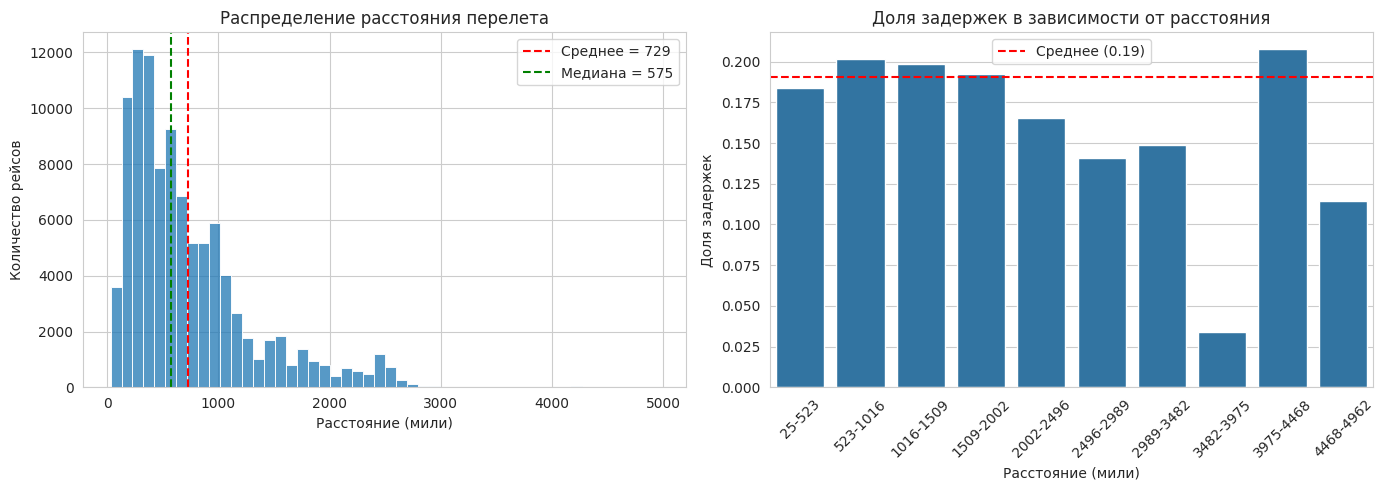

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение расстояния
if 'Distance' in train_processed.columns:
    sns.histplot(train_processed['Distance'], bins=50, ax=axes[0])
    axes[0].set_title('Распределение расстояния перелета')
    axes[0].set_xlabel('Расстояние (мили)')
    axes[0].set_ylabel('Количество рейсов')
    # Добавляем статистику
    axes[0].axvline(train_processed['Distance'].mean(), color='r', linestyle='--', label=f'Среднее = {train_processed["Distance"].mean():.0f}')
    axes[0].axvline(train_processed['Distance'].median(), color='g', linestyle='--', label=f'Медиана = {train_processed["Distance"].median():.0f}')
    axes[0].legend()

# Задержка в зависимости от расстояния (ИСПРАВЛЕННАЯ ВЕРСИЯ)
if 'Distance' in train_processed.columns and 'target' in train_processed.columns:
    # Группируем расстояние по корзинам
    train_processed['Distance_bin'] = pd.cut(train_processed['Distance'], bins=10)
    # Используем observed=False для подавления предупреждения
    distance_delay = train_processed.groupby('Distance_bin', observed=False)['target'].mean()
    
    # Создаем понятные метки для корзин
    bin_labels = [f'{int(interval.left)}-{int(interval.right)}' for interval in distance_delay.index]
    
    sns.barplot(x=bin_labels, y=distance_delay.values, ax=axes[1])
    axes[1].set_title('Доля задержек в зависимости от расстояния')
    axes[1].set_xlabel('Расстояние (мили)')
    axes[1].set_ylabel('Доля задержек')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].axhline(y=delay_rate, color='r', linestyle='--', label=f'Среднее ({delay_rate:.2f})')
    axes[1].legend()

plt.tight_layout()
plt.show()

# Удаляем временную колонку, чтобы не мешала
if 'Distance_bin' in train_processed.columns:
    train_processed = train_processed.drop('Distance_bin', axis=1)

# Проверка пропущенных значений:

In [10]:
# Проверка пропущенных значений
missing_train = train_processed.isnull().sum()
missing_test = test_processed.isnull().sum()

print("ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ:")
print("\nTrain:")
print(missing_train[missing_train > 0] if any(missing_train > 0) else "Нет пропущенных значений")
print("\nTest:")
print(missing_test[missing_test > 0] if any(missing_test > 0) else "Нет пропущенных значений")

ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ:

Train:
Нет пропущенных значений

Test:
Нет пропущенных значений


In [11]:
import json

def convert_to_serializable(obj):

    if isinstance(obj, (np.integer, np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64, np.float32)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, pd.Series):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {key: convert_to_serializable(value) for key, value in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(item) for item in obj]
    else:
        return obj

try:
    eda_stats = {
        'total_flights': int(len(train_processed)),
        'delay_rate': float(delay_rate),
        'avg_distance': float(train_processed['Distance'].mean()),
        'median_distance': float(train_processed['Distance'].median()),
        'std_distance': float(train_processed['Distance'].std()),
        'peak_hour': int(train_processed['DepHour'].mode()[0]),
        'busiest_day': int(train_processed['DayOfWeek'].mode()[0]),
        'carrier_with_highest_delay': str(train_processed.groupby('UniqueCarrier')['target'].mean().idxmax()),
        'carrier_with_lowest_delay': str(train_processed.groupby('UniqueCarrier')['target'].mean().idxmin()),
        'n_carriers': int(train_processed['UniqueCarrier'].nunique()),
        'n_airports_origin': int(train_processed['Origin'].nunique()),
        'n_airports_dest': int(train_processed['Dest'].nunique()),
        'min_distance': float(train_processed['Distance'].min()),
        'max_distance': float(train_processed['Distance'].max()),
        'q1_distance': float(train_processed['Distance'].quantile(0.25)),
        'q3_distance': float(train_processed['Distance'].quantile(0.75)),
    }
    
    hourly_distribution = train_processed.groupby('DepHour')['target'].mean().to_dict()
    eda_stats['hourly_delay_distribution'] = {str(k): float(v) for k, v in hourly_distribution.items()}

    weekly_distribution = train_processed.groupby('DayOfWeek')['target'].mean().to_dict()
    eda_stats['weekly_delay_distribution'] = {str(k): float(v) for k, v in weekly_distribution.items()}

    carrier_delay = train_processed.groupby('UniqueCarrier')['target'].mean().sort_values(ascending=False)
    eda_stats['top_5_delayed_carriers'] = {
        str(k): float(v) for k, v in carrier_delay.head(5).items()
    }
    eda_stats['top_5_punctual_carriers'] = {
        str(k): float(v) for k, v in carrier_delay.tail(5).items()
    }

    eda_stats_serializable = convert_to_serializable(eda_stats)

    with open('/kaggle/working/eda_stats.json', 'w') as f:
        json.dump(eda_stats_serializable, f, indent=4, ensure_ascii=False)
    
    print("\n")
    print("СОХРАНЕННЫЕ СТАТИСТИКИ (EDA):")
    print("\n")
    for key, value in eda_stats.items():
        if not isinstance(value, dict):
            print(f"  {key}: {value}")
    
    print("\n")
    print("РАСПРЕДЕЛЕНИЕ ЗАДЕРЖЕК ПО ЧАСАМ:")
    print("\n")
    for hour, delay in sorted(eda_stats['hourly_delay_distribution'].items()):
        print(f"  Час {hour}: {delay:.3f}")
    
    print("\n")
    print("РАСПРЕДЕЛЕНИЕ ЗАДЕРЖЕК ПО ДНЯМ НЕДЕЛИ:")
    print("\n")
    days = {1: 'ПН', 2: 'ВТ', 3: 'СР', 4: 'ЧТ', 5: 'ПТ', 6: 'СБ', 7: 'ВС'}
    for day, delay in sorted(eda_stats['weekly_delay_distribution'].items()):
        print(f"  {days[int(day)]}: {delay:.3f}")
    
    print("\n")
    print("ТОП-5 АВИАКОМПАНИЙ ПО ЗАДЕРЖКАМ:")
    print("\n")
    for carrier, delay in eda_stats['top_5_delayed_carriers'].items():
        print(f"  {carrier}: {delay:.3f}")
    
    print("\n")
    print("ТОП-5 ПУНКТУАЛЬНЫХ АВИАКОМПАНИЙ:")
    print("\n")
    for carrier, delay in eda_stats['top_5_punctual_carriers'].items():
        print(f"  {carrier}: {delay:.3f}")
    
    print("\n EDA статистика сохранена в 'eda_stats.json'")
    print(f"   Размер файла: {os.path.getsize('/kaggle/working/eda_stats.json') / 1024:.1f} KB")

except Exception as e:
    print(f" Ошибка при сохранении статистики: {e}")
    print("Продолжаем выполнение...")



СОХРАНЕННЫЕ СТАТИСТИКИ (EDA):


  total_flights: 100000
  delay_rate: 0.19044
  avg_distance: 729.39716
  median_distance: 575.0
  std_distance: 574.6168595588642
  peak_hour: 8
  busiest_day: 4
  carrier_with_highest_delay: EV
  carrier_with_lowest_delay: HA
  n_carriers: 22
  n_airports_origin: 289
  n_airports_dest: 289
  min_distance: 30.0
  max_distance: 4962.0
  q1_distance: 317.0
  q3_distance: 957.0


РАСПРЕДЕЛЕНИЕ ЗАДЕРЖЕК ПО ЧАСАМ:


  Час 0: 0.545
  Час 1: 0.605
  Час 10: 0.133
  Час 11: 0.150
  Час 12: 0.172
  Час 13: 0.194
  Час 14: 0.197
  Час 15: 0.224
  Час 16: 0.234
  Час 17: 0.238
  Час 18: 0.280
  Час 19: 0.305
  Час 2: 0.444
  Час 20: 0.337
  Час 21: 0.390
  Час 22: 0.431
  Час 23: 0.475
  Час 3: 0.625
  Час 4: 0.079
  Час 5: 0.007
  Час 6: 0.025
  Час 7: 0.057
  Час 8: 0.077
  Час 9: 0.113


РАСПРЕДЕЛЕНИЕ ЗАДЕРЖЕК ПО ДНЯМ НЕДЕЛИ:


  ПН: 0.190
  ВТ: 0.168
  СР: 0.177
  ЧТ: 0.212
  ПТ: 0.224
  СБ: 0.167
  ВС: 0.192


ТОП-5 АВИАКОМПАНИЙ ПО ЗАДЕРЖКАМ:


  EV: 0.275


In [12]:
# 10. ФИНАЛЬНАЯ ПРОВЕРКА
print("\n")
print("ФИНАЛЬНАЯ ПРОВЕРКА:")
print("\n")
# Проверяем, что все необходимые колонки присутствуют
required_columns_train = ['Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'DepHour', 
                          'IsWeekend', 'UniqueCarrier', 'Origin', 'Dest', 'Distance', 'target']
missing_in_train = [col for col in required_columns_train if col not in train_processed.columns]

if missing_in_train:
    print(f"Отсутствуют колонки в Train: {missing_in_train}")
else:
    print("Все необходимые колонки присутствуют в Train")

required_columns_test = ['Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'DepHour', 
                         'IsWeekend', 'UniqueCarrier', 'Origin', 'Dest', 'Distance']
missing_in_test = [col for col in required_columns_test if col not in test_processed.columns]

if missing_in_test:
    print(f"Отсутствуют колонки в Test: {missing_in_test}")
else:
    print("Все необходимые колонки присутствуют в Test")

print("Данные сохранены и готовы к моделированию.")



ФИНАЛЬНАЯ ПРОВЕРКА:


Все необходимые колонки присутствуют в Train
Все необходимые колонки присутствуют в Test
Данные сохранены и готовы к моделированию.
